In [3]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# 线检测

In [4]:
img = cv.imread("./image/rili.jpg")
# 投票数越高 → 越多边缘点共线 → 这条直线越显著。



In [5]:
edges = cv.Canny(img, 50, 150)

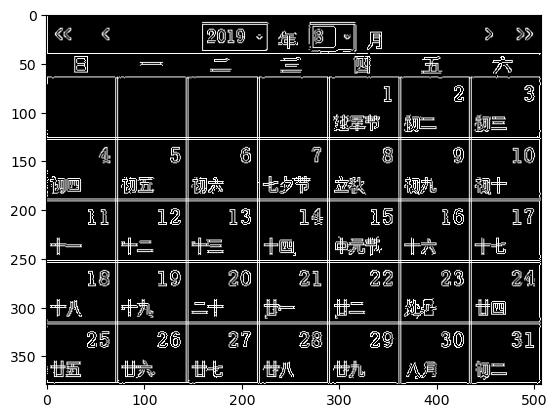

In [6]:
plt.imshow(edges, cmap=plt.cm.gray)

In [7]:
lines = cv.HoughLines(edges, 0.8, np.pi / 180, 150)

In [8]:
for line in lines:
    rho, theta = line[0]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = rho * a
    y0 = rho * b
    #     直线的极坐标方程为：
    #
    # ρ = x·cosθ + y·sinθ
    #
    # 直线的法向量（垂直于直线的方向）为：
    #
    # n = (cosθ, sinθ)
    #
    # 直线的方向向量（沿直线的方向）为：
    #
    # d = (-sinθ, cosθ)（法向量逆时针旋转 90°）
    # 接下来是关键：用垂足沿直线方向延伸，得到两个端点
    #
    # 直线的方向向量为 (-b, a)（因为 -sinθ, cosθ）。
    #
    # 取 t = 1000 和 t = -1000（1000 是一个足够大的数，确保端点超出图像边界）：
    #
    # python
    # # 端点1：从垂足沿方向向量移动 +1000 步
    # x1 = int(x0 + 1000 * (-b))    # x1 = x0 + t * (-b)
    # y1 = int(y0 + 1000 * a)       # y1 = y0 + t * a
    #
    # # 端点2：从垂足沿方向向量移动 -1000 步
    # x2 = int(x0 - 1000 * (-b))    # x2 = x0 - t * (-b)
    # y2 = int(y0 - 1000 * a)       # y2 = y0 - t * a
    x1 = int(x0 + 10000 * (-b))
    y1 = int(y0 + 10000 * a)
    x2 = int(x0 - 10000 * (-b))
    y2 = int(y0 - 10000 * a)
    cv.line(img, (x1, y1), (x2, y2), (0, 255, 0))


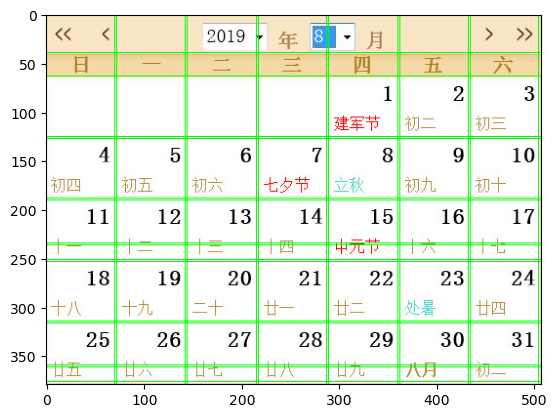

In [9]:
plt.imshow(img[:, :, ::-1])

# 圆检测

In [10]:
star = cv.imread("./image/star.jpeg")

In [11]:
gray_img = cv.cvtColor(star, cv.COLOR_BGR2GRAY)

In [12]:
img = cv.medianBlur(gray_img, 7)

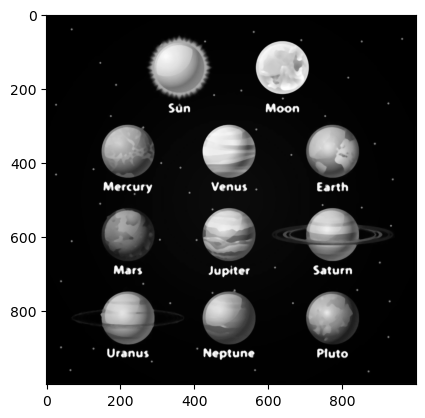

In [13]:
plt.imshow(img, cmap=plt.cm.gray)

In [36]:
circles = cv.HoughCircles(img, cv.HOUGH_GRADIENT, 1, 200, param1=100, param2=50, minRadius=0, maxRadius=100)

In [37]:
print(circles)
print(circles.shape)
print( circles[0, :].shape)

[[[494.5 370.5  71.9]
  [774.5 821.5  71.2]
  [494.5 596.5  71.3]
  [221.5 370.5  72. ]
  [774.5 370.5  72. ]
  [220.5 595.5  71. ]
  [220.5 820.5  71.6]
  [493.5 820.5  70.9]
  [774.5 594.5  70.6]
  [358.5 142.5  78. ]
  [639.5 149.5  69.1]]]
(1, 11, 3)
(11, 3)


In [38]:
# for i in circles[0, :]:
#     cv.circle(star, (i[0], i[1]), i[2], (0, 255, 0), 2)
#     cv.circle(star, (i[0], i[1]), 2, (0, 255, 0), -1)
#
# 假设 circles 已经通过 HoughCircles 得到
if circles is not None:
    # 转换为整数：四舍五入并转为 int 类型
    circles = np.round(circles[0, :]).astype(int)

    for (x, y, r) in circles:
        cv.circle(star, (x, y), r, (0, 255, 0), 26)
        cv.circle(star, (x, y), 2, (0, 255, 0), cv.FILLED)


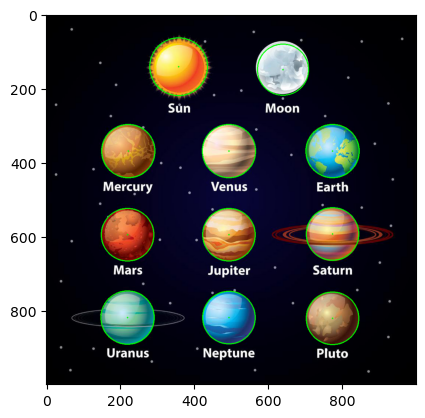

In [34]:
plt.imshow(star[:, :, ::-1])